# Exploratory Data Analysis (EDA)

En initial EDA genomfördes för att skapa en förståelse för hur datan är strukturerad och segmenterad.

Datan består av JSON-filer där varje fil representerar en lektion. Dessa lektioner är organiserade i en hierarkisk struktur där:
- lektioner tillhör kapitel
- kapitel tillhör kurser

Detta innebär att datan redan innehåller en viss semantisk struktur, vilket potentiellt kan utnyttjas i modellen, exempelvis när vi sedan skapar chunks

Utöver denna initiala analys genomfördes EDA även löpande under projektets gång, exempelvis vid:
- datainsamling
- utveckling av chunking-strategi
- felsökning av retrieval-resultat

Datan har även kollats upp mot e-learningplattformen vilket varit ett bra verktyg för att lära känna datat. Jag har även läst igenom HELA elearningen dock för 4 år sedan....

Fokus i denna initiala EDA var att analysera textlängd per lektion för att kunna designa en lämplig chunking-strategi.

Resultatet visade att:
- de flesta lektioner låg runt ~1050 tecken
- det förekom extrema värden både med mycket korta och mycket långa texter

Detta innebär och visade sig också att en statisk chunking-strategi inte är optimal, utan att chunking behöver anpassas efter kursernas och kapitlens struktur men också dess längd såklart.

In [1]:
#Import
import os
import json
import numpy as np
import matplotlib.pyplot as plt

## Testar på en kurs före full skala

Innan jag gav mig på all data som är 11 kurser så testade jag först hela mitt tänkta flöde på en kurs. Syftet var att verifiera att min tanke fungerade från början till slut. Jag gjorde följande på denna kursen

- chunking
- embeddings
- retrieval test
- RAG-test

Detta fungerade som en proof of concept innan jag skalade upp till hela datamängden. Genom att börja i liten skala blev det enklare att identifiera problem och justera upplägget innan mer data introducerades. Denna modellen finns med som en notebook och heter Testmodell_1kurs.ipynb, den är väldigt basic

In [2]:
# Syfte: Analysera textlängd per lektion för att designa chunking i RAG-modellen

folder_path = r"C:\YA BI analyst\Kurser\BI25M AI & IoT\Kunskapskontroll 1\AI-IoT-Kunskapskrav-1\data\cleaned\3064200"

lengths = []

# Går igenom alla JSON-filer (en fil = en lektion)
for root, _, files in os.walk(folder_path):
    for file in files:
        if file.endswith(".json"):
            path = os.path.join(root, file)

            with open(path, "r", encoding="utf-8") as f:
                data = json.load(f)
                text = data.get("text", "")

                lengths.append(len(text))

# Statistik över textlängder
print(f"Antal filer: {len(lengths)}")
print(f"Min: {min(lengths)}")
print(f"Max: {max(lengths)}")
print(f"Medel: {np.mean(lengths):.0f}")
print(f"Median: {np.median(lengths):.0f}")

Antal filer: 5
Min: 96
Max: 2022
Medel: 1149
Median: 1358


## Undersöker alla kurser

Undersöker mängden och fördelningen av data

In [3]:
folder_path = r"C:\YA BI analyst\Kurser\BI25M AI & IoT\Kunskapskontroll 1\AI-IoT-Kunskapskrav-1\data\cleaned"

# Syfte: Läsa in alla lektioner och returnera text + metadata
def load_lessons(folder_path):
    lessons = []

    for root, _, files in os.walk(folder_path):
        for file in files:
            if file.endswith(".json"):
                path = os.path.join(root, file)

                with open(path, "r", encoding="utf-8") as f:
                    data = json.load(f)

                    lessons.append({
                        "file": file,
                        "path": path,
                        "text": data.get("text", "")
                    })

    return lessons

In [4]:
lessons = load_lessons(folder_path)

lengths = [len(l["text"]) for l in lessons]

print(f"Antal filer: {len(lengths)}")
print(f"Min: {min(lengths)}")
print(f"Max: {max(lengths)}")

Antal filer: 349
Min: 0
Max: 16069


In [5]:
# Syfte: Identifiera hur många lektioner som saknar text 
lessons = load_lessons(folder_path)

# Filtrerar ut lektioner utan innehåll
empty_lessons = [l for l in lessons if not l["text"].strip()]

total_count = len(lessons)
empty_count = len(empty_lessons)

print(f"Totalt antal filer: {total_count}")
print(f"Tomma filer: {empty_count}")

Totalt antal filer: 349
Tomma filer: 37


In [6]:
# Skapa lista med antal tecken
files_with_lengths = [
    {
        "file": l["file"],
        "path": l["path"],
        "length": len(l["text"])
    }
    for l in lessons
]

# Sortera
files_with_lengths.sort(key=lambda x: x["length"], reverse=True)

print(f" \nTop 10 \n") 

# Top 10
for i, item in enumerate(files_with_lengths[:10], 1):
    print(f"{i}. {item['file']} - {item['length']} tecken")


# Sortera
files_with_lengths.sort(key=lambda x: x["length"], reverse=False)

print(f" \nBot 10 (utan tomma) \n")  

# Bot 10 (utan de tomma)
for i, item in enumerate(files_with_lengths[37:47], 1):
    print(f"{i}. {item['file']} - {item['length']} tecken")

 
Top 10 

1. 22418568.json - 16069 tecken
2. 63938572.json - 4618 tecken
3. 11088998.json - 4447 tecken
4. 11123484.json - 4305 tecken
5. 11474273.json - 4089 tecken
6. 11088961.json - 4007 tecken
7. 11088939.json - 3613 tecken
8. 11304356.json - 3604 tecken
9. 11472057.json - 3603 tecken
10. 11444963.json - 3594 tecken
 
Bot 10 (utan tomma) 

1. 10956955.json - 9 tecken
2. 10957013.json - 9 tecken
3. 10957041.json - 9 tecken
4. 11333504.json - 58 tecken
5. 11333509.json - 67 tecken
6. 11472145.json - 68 tecken
7. 11548770.json - 70 tecken
8. 63949184.json - 96 tecken
9. 11542593.json - 110 tecken
10. 64129365.json - 146 tecken


Här vill jag se hur många filer vi har utan text. Detta kan vara filer med bilder eller videos som jag vet att det finnns massvis med i elearningen men som är utanför denna uppgiftens scope.
Det visade sig vara 37 tomma filer. Dessa ska hanteras senare.

===== STATISTIK =====
Antal filer: 312
Min längd: 9 tecken
Max längd: 16069 tecken
Medellängd: 1274.46 tecken
Medianlängd: 1054.00 tecken


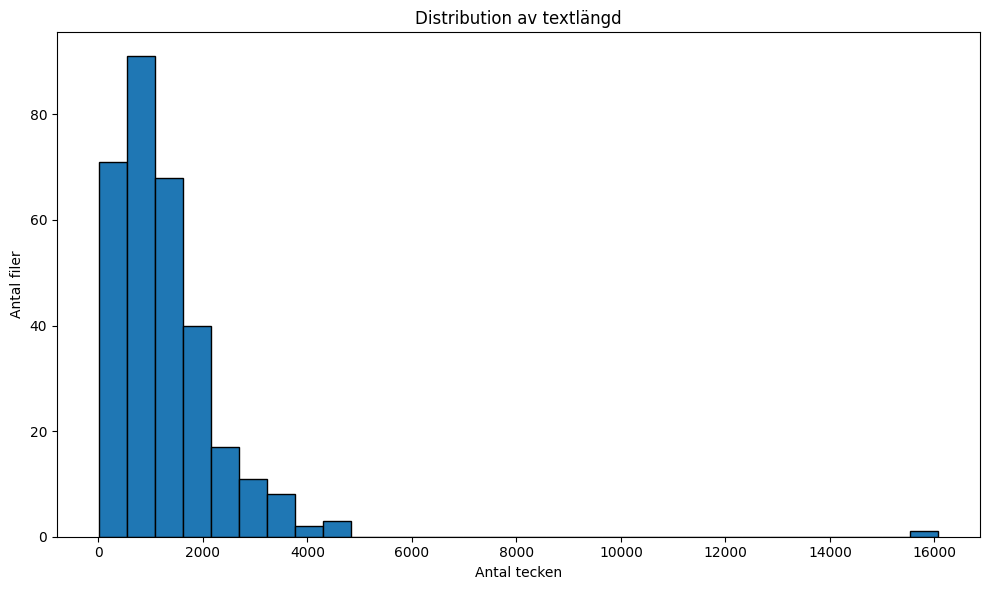

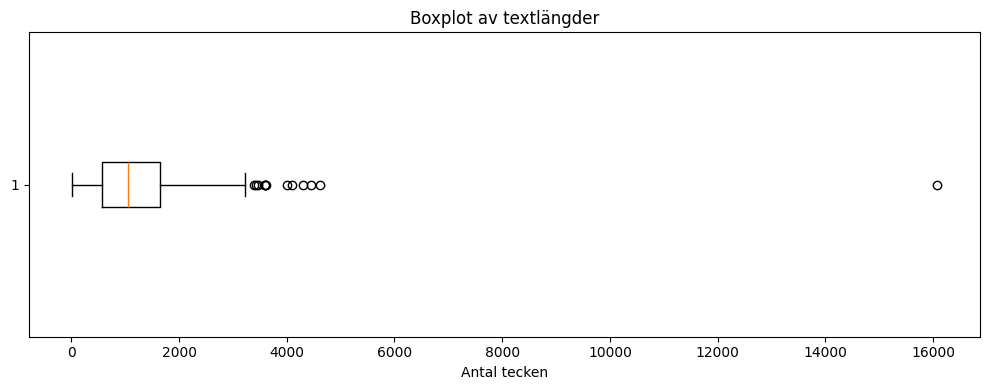

In [8]:
# Syfte: Analysera textlängder i datasetet för att förstå distribution,
# identifiera extremvärden och designa en lämplig chunking-strategi

# Sökväg till rensad data (en JSON-fil per lektion)
folder_path = r"C:\YA BI analyst\Kurser\BI25M AI & IoT\Kunskapskontroll 1\AI-IoT-Kunskapskrav-1\data\cleaned"

# Samlingar för analys
lengths = []              # Enbart längder för statistik och visualisering

# Loopar igenom alla undermappar och JSON-filer
for root, _, files in os.walk(folder_path):
    for file in files:
        if file.endswith(".json"):
            path = os.path.join(root, file)

            # Läser in JSON-filen
            with open(path, "r", encoding="utf-8") as f:
                data = json.load(f)

            text = data.get("text", "")

            # Filtrerar bort tomma eller ogiltiga texter
            # eftersom de inte tillför något i senare steg
            if not isinstance(text, str) or not text.strip():
                continue

            length = len(text)

            # Sparar längden för statistik och visualisering
            lengths.append(length)


# Kontroll att data faktiskt finns
if not lengths:
    print("Inga giltiga JSON-filer med text hittades.")

else:
    print("===== STATISTIK =====")
    print(f"Antal filer: {len(lengths)}")
    print(f"Min längd: {min(lengths)} tecken")
    print(f"Max längd: {max(lengths)} tecken")
    print(f"Medellängd: {np.mean(lengths):.2f} tecken")
    print(f"Medianlängd: {np.median(lengths):.2f} tecken")

    # Histogram visar hur textlängderna är fördelade
    plt.figure(figsize=(10, 6))
    plt.hist(lengths, bins=30, edgecolor="black")
    plt.title("Distribution av textlängd")
    plt.xlabel("Antal tecken")
    plt.ylabel("Antal filer")
    plt.tight_layout()
    plt.show()

    # Boxplot visar spridning och extremvärden tydligare
    plt.figure(figsize=(10, 4))
    plt.boxplot(lengths, vert=False)
    plt.title("Boxplot av textlängder")
    plt.xlabel("Antal tecken")
    plt.tight_layout()
    plt.show()